<a href="https://colab.research.google.com/github/Syed-Bilal-Hussaini/Task-10/blob/main/Task_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from sklearn.datasets import load_digits

digits = load_digits()
x,y = digits.data , digits.target

In [11]:
{x.shape}

{(1797, 64)}

In [9]:
print(f"Labels (y) shape: {y.shape}")

Labels (y) shape: (1797,)


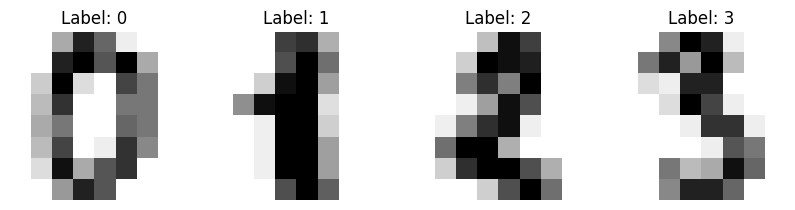

In [12]:
import matplotlib.pyplot as plt

# Plotting the first 4 images
_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, image, label in zip(axes, digits.images, digits.target):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title(f"Label: {label}")

In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train_scaled, y_train)

y_pred = knn.predict(x_test_scaled)
print(f"Accuracy with K=3: {accuracy_score(y_test, y_pred):.4f}")

Accuracy with K=3: 0.9694


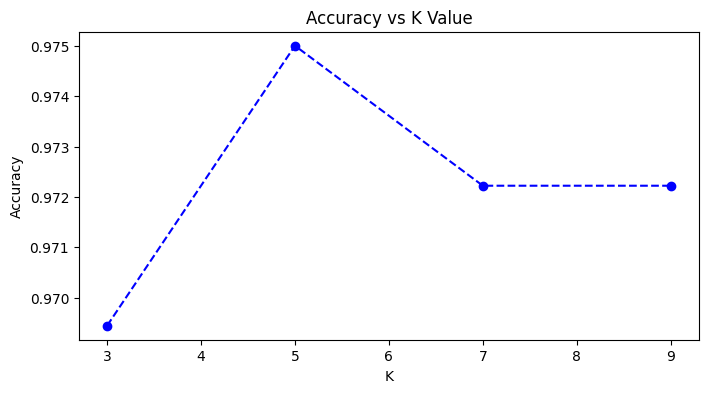

In [20]:
k_values = [3, 5, 7, 9]
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train_scaled, y_train)
    acc = model.score(x_test_scaled, y_test)
    accuracies.append(acc)

plt.figure(figsize=(8, 4))
plt.plot(k_values, accuracies, marker='o', linestyle='--', color='b')
plt.title('Accuracy vs K Value')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.show()

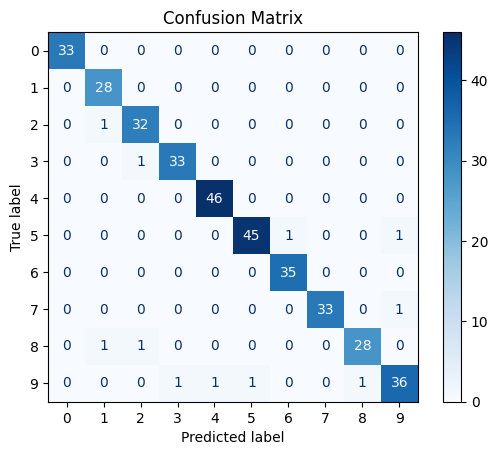

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(knn, x_test_scaled, y_test, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

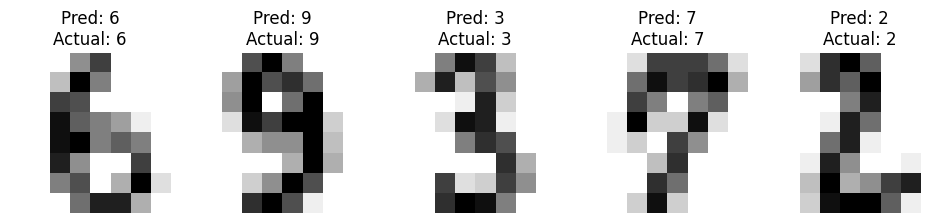

In [24]:
sample_preds = knn.predict(x_test_scaled[:5])

_, axes = plt.subplots(nrows=1, ncols=5, figsize=(12, 3))
for ax, image, pred, actual in zip(axes, x_test[:5], sample_preds, y_test[:5]):
    ax.set_axis_off()
    # Reshape the flattened 64 pixels back to 8x8 for display
    ax.imshow(image.reshape(8, 8), cmap=plt.cm.gray_r)
    ax.set_title(f"Pred: {pred}\nActual: {actual}")